In [1]:
from pathlib import Path
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from pytorch_lightning.core.lightning import LightningModule
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.chdir('/home/kai/DigitalICU/Experiments/HIRID-PatientStateSpace/')

from utils.config_dataset import *
from utils.ClassDataset import MergedDataset
from utils.ClassSOM import VASO_PHYSIO_PRED, VASO_PHYSIO_PRED_MONO
from utils.data_io import load_train_test_dataset

RANDOMSEED = 2024
torch.manual_seed(RANDOMSEED)
np.random.seed(RANDOMSEED)

def mae_loss(x_, x, los=False):
    if los:
        loss = np.mean(np.abs(x - x_))
    else:
        mask_valid = np.where(x!=-1)
        loss = np.mean(np.abs(x[mask_valid] - x_[mask_valid]))
    return loss

norm_params = pickle.load(open('processed-merge/norm_params_vasopressor.p', 'rb'))

def de_norm(data, col, norm_params=norm_params):
    norm_min = norm_params[col].loc['0.1%']
    norm_max = norm_params[col].loc['99.9%']
    data_ = data * (norm_max - norm_min) + norm_min
    return data_

selected_physio = ['HR', 'RR', 'SpO2', 'ABPd', 'ABPm', 'ABPs', 'ZVD']
selected_med = ['norepinephrine', 'epinephrine', 'dobutamine']

In [2]:
def plot_vital_pred(idx):
    sample = dataset_test[idx]
    x = sample['data']
    x[np.where(x==-1)] = np.nan
    x_ = X_reconstructed[idx]
    x_[np.where(x_==-1)] = np.nan
    x_next = X_pred[idx]
    x_next[np.where(x_next==-1)] = np.nan
    meds = ['dobutamine', 'epinephrine', 'norepinephrine']
    med_label = meds[np.where(sample['med_label']==1)[0].item()]
    x_med = sample['med']
    x_med[np.where(x_med==0)] = np.nan

    labels = selected_physio

#     fig = plt.figure(figsize=(16,8))
#     gs = fig.add_gridspec(8,3)
#     ax = []
#     for i in range(6):
#         if i == 0:
#             ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3]))
            
        
#     ax.append(fig.add_subplot(gs[6:, :]))
    fig, ax = plt.subplots(2,3,figsize=(16,8), sharex=True)
    colors = plt.cm.tab10
    physio_plot = [
        'HR',
        'RR',
        'SpO2',
        'ABPd',
        'ABPs',
        'ZVD',
    ]
    for i, physio in enumerate(physio_plot):
        idx_physio = PHYSIO_BENCHMARK.index(physio)

        x_raw = de_norm(x[:,idx_physio], physio)
        x_pred = de_norm(x_next[:,idx_physio], physio)

        ax[i//3][i%3].plot(range(180), x_raw, '-', color=colors(0))
        ax[i//3][i%3].plot(range(90, 180), x_pred, '--', color=colors(1))
        ax[i//3][i%3].set_title(f"{med_label} - {physio}")
    lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
             Line2D([0], [0], color=colors(1), lw=1, label='prediction')]
    plt.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.1)); 
    ax[1][2].set_xlim([0, 180])
    ax[1][2].set_xticks(np.arange(0, 180, 30))
    ax[1][2].set_xticklabels(np.arange(0, 360, 60))
    ax[1][0].set_xlabel('time [min]')
    ax[1][1].set_xlabel('time [min]')
    ax[1][2].set_xlabel('time [min]')

    fig, ax = plt.subplots(1, 1, figsize=(16,3))
    lines = []
    for med in MED_BENCHMARK[:3]:
        idx_med = MED_BENCHMARK.index(med)
        med_raw =  de_norm(x_med[:, idx_med], med)
        med_raw[np.where(med_raw==0)] = np.nan
        ax.plot(med_raw, label=med, color=colors(idx_med))
        lines.append(Line2D([0], [0], color=colors(idx_med), lw=1, label=med))
    ax.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));
    ax.set_xlim([0, 180])
    ax.set_xticks(np.arange(0, 180, 15))
    ax.set_xticklabels(np.arange(0, 360, 30))
    ax.set_xlabel('time [min]')
    return med_label, fig

In [3]:
def gridplot_vital_pred(idx):
    sample = dataset_test[idx]
    x = sample['data']
    x[np.where(x==-1)] = np.nan
    x_ = X_reconstructed[idx]
    x_[np.where(x_==-1)] = np.nan
    x_next = X_pred[idx]
    x_next[np.where(x_next==-1)] = np.nan
    meds = ['dobutamine', 'epinephrine', 'norepinephrine']
    med_label = meds[np.where(sample['med_label']==1)[0].item()]
    x_med = sample['med']
    x_med[np.where(x_med==0)] = np.nan

    labels = selected_physio

    fig = plt.figure(figsize=(16,10))
    gs = fig.add_gridspec(9,3)
    ax = []
    for i in range(6):
        if i == 0:
            ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3]))
        else:
            ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3], sharex=ax[0]))
    ax.append(fig.add_subplot(gs[6:,:]))
    
    colors = plt.cm.tab10
    physio_plot = [
        'HR',
        'RR',
        'SpO2',
        'ABPd',
        'ABPs',
        'ZVD',
    ]
    for i, physio in enumerate(physio_plot):
        idx_physio = PHYSIO_BENCHMARK.index(physio)

        x_raw = de_norm(x[:,idx_physio], physio)
        x_pred = de_norm(x_next[:,idx_physio], physio)

        ax[i].plot(range(180), x_raw, '-', color=colors(0))
        ax[i].plot(range(90, 180), x_pred, '--', color=colors(1))
        ax[i].set_title(f"{med_label} - {physio}", fontsize=14)
    lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
             Line2D([0], [0], color=colors(1), lw=1, label='prediction')]
    ax[5].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.15), fontsize=12); 
    ax[5].set_xlim([0, 180])
    ax[5].set_xticks(np.arange(0, 180, 30))
    ax[5].set_xticklabels(np.arange(0, 360, 60))
#     ax[3].set_xlabel('time [min]')
#     ax[4].set_xlabel('time [min]')
#     ax[5].set_xlabel('time [min]')

    lines = []
    for med in MED_BENCHMARK[:3]:
        idx_med = MED_BENCHMARK.index(med)
        med_raw =  de_norm(x_med[:, idx_med], med)
        med_raw[np.where(med_raw==0)] = np.nan
        ax[6].plot(med_raw, label=med, color=colors(idx_med))
        lines.append(Line2D([0], [0], color=colors(idx_med), lw=1, label=med))
    ax[6].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12);
    ax[6].set_xlim([0, 180])
    ax[6].set_xticks(np.arange(0, 180, 15))
    ax[6].set_xticklabels(np.arange(0, 360, 30))
    ax[6].set_xlabel('time [min]')
    ax[6].set_title('Medication administration', fontsize=14)
    
    plt.subplots_adjust(hspace=2.5, wspace=.3)
    return med_label, fig

In [5]:
# model_path = 'models/VASO_PHYSIO_PRED/CNN-196hidden-8som-3r-0.1dropout-8-0.0005/version_0'
# model_file = os.path.join(model_path, "epoch94-val_loss0.58486.ckpt")
# model_path = 'models/VASO_PHYSIO_PRED/CNN-196hidden-8som-3r-0.1dropout-8-0.0005/version_6/'
# model_file = os.path.join(model_path, 'epoch73-val_loss0.34688.ckpt')
model_path = 'models/VASO_PHYSIO_PRED_MONO/CNN-63hidden-10som-1r-0.1dropout-8-0.0005/version_0/'
model_file = os.path.join(model_path, 'epoch133-val_loss_pred0.05934.ckpt')

config_file = os.path.join(model_path, "model_config.p")

device = 'cuda'

 # load data
print("Loading dataset")
data_path = 'processed-merge/'
pid_valid = pickle.load(open(os.path.join(data_path, 'pid_valid_00.p'), 'rb'))
patient_info = pickle.load(open(os.path.join(data_path, 'patient_info.p'), 'rb'))
sample_dict = pickle.load(open(os.path.join(data_path, 'sample_dict_vasopressor.p'), 'rb'))
norm_params = pickle.load(open('processed-merge/norm_params_vasopressor.p', 'rb'))
norm_params_info = pickle.load(open('processed-merge/norm_params_info_vasopressor.p', 'rb'))

dischargestatus = []
for i in sample_dict:
    status = patient_info.loc[patient_info['patientid'] == sample_dict[i][1], 'discharge_status'].item()
    label = 1 if status == 'dead' else 0
    dischargestatus.append(label)
dischargestatus = np.array(dischargestatus)

selected_physio = ['HR', 'RR', 'SpO2', 'ABPd', 'ABPm', 'ABPs', 'ZVD']
selected_med = ['norepinephrine', 'epinephrine', 'dobutamine']
train_test_indices = pickle.load(open(os.path.join(data_path, 'train_test_split_vasopressor.p'), 'rb'))
sampleid_train, sampleid_test = train_test_indices['train'], train_test_indices['test']
sampleid_tr, sampleid_val = train_test_split(sampleid_train, test_size=0.2, random_state=RANDOMSEED,
                                   stratify=dischargestatus[sampleid_train])

dataset_val = MergedDataset(sample_dict={item[0]: item[1] for item in sample_dict.items() if item[0] in sampleid_val},
                              df_info=patient_info, norm=True, selected_physio=selected_physio,selected_med=selected_med)
dataset_test = MergedDataset(sample_dict={item[0]: item[1] for item in sample_dict.items() if item[0] in sampleid_test},
                              df_info=patient_info, norm=True, selected_physio=selected_physio,selected_med=selected_med)
loader_val = DataLoader(dataset_val, batch_size=16, shuffle=False, num_workers=32)
loader_test = DataLoader(dataset_test, batch_size=16, shuffle=False, num_workers=16)

# Train model
config = pickle.load(open(config_file, 'rb'))

try:
    model = VASO_PHYSIO_PRED.load_from_checkpoint(checkpoint_path=model_file, config=config)
except:
    model = VASO_PHYSIO_PRED_MONO.load_from_checkpoint(checkpoint_path=model_file, config=config)
model.to(device)
model.eval()

Loading dataset


VASO_PHYSIO_PRED_MONO(
  (encoder_ae): Sequential(
    (0): Conv1d(7, 35, kernel_size=(6,), stride=(3,), groups=7)
    (1): ReLU()
    (2): Conv1d(35, 7, kernel_size=(5,), stride=(3,))
    (3): ReLU()
  )
  (decoder_ae): Sequential(
    (0): ConvTranspose1d(7, 35, kernel_size=(5,), stride=(3,))
    (1): ReLU()
    (2): ConvTranspose1d(35, 7, kernel_size=(6,), stride=(3,), groups=7)
    (3): Sigmoid()
  )
  (encoder_med): Sequential(
    (0): Conv1d(7, 35, kernel_size=(6,), stride=(3,), groups=7)
    (1): ReLU()
    (2): Conv1d(35, 7, kernel_size=(5,), stride=(3,))
    (3): ReLU()
  )
  (encoder_info): Sequential(
    (0): LazyLinear(in_features=0, out_features=16, bias=True)
    (1): ReLU()
  )
  (encoder_physio_addon): Sequential(
    (0): Linear(in_features=79, out_features=63, bias=True)
  )
  (state_transition): Sequential(
    (0): Linear(in_features=79, out_features=63, bias=True)
    (1): ReLU()
    (2): Linear(in_features=63, out_features=63, bias=True)
  )
  (monotonic_layer):

In [14]:
fc1_weight = model.monotonic_layer.nn[0].weight.detach()

In [15]:
fc1_weight.shape

torch.Size([35, 70])

In [17]:
fc1_weight[:, -7:]

tensor([[-0.2880,  0.2427, -0.0788,  1.0000,  1.0000,  1.0000,  1.0000],
        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
        [ 0.9885,  0.7827,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000],
        [-0.7111,  0.0080, -0.3089,  1.0000,  1.0000,  1.0000,  1.0000],
        [ 0.8256, -0.0835, -0.3155,  0.4498,  0.3851,  0.5282,  0.5359],
        [-0.0627, -0.2808,  0.0491, -0.3933, -0.3325, -0.0617, -0.3200],
        [ 0.1880, -0.2357, -0.0482, -0.0591,  0.0646,  0.2816,  0.1392],
        [-0.5352,  0.3290, -0.2383,  0.2162, -0.1318,  0.1133,  0.0625],
        [ 1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000],
        [-1.0000, -1.0000, -1.0000, -0.8520, -1.0000, -1.0000, -1.0000],
        [ 1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000],
        [-0.1627, -0.0363, -0.1995, -0.6212,  0.2524,  0.2593, -0.0581],
        [-0.2674,  0.3782, -0.1863, -0.1244, -0.4233, -0.4494, -0.3046],
        [-1.0000,  0.1148, -0.1815, -0.1349, -0.167

In [7]:
activation = {}
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

In [ ]:

model.fc2.register_forward_hook(get_activation('fc2'))
x = torch.randn(1, 25)
output = model(x)
print(activation['fc2'])

In [8]:
model.monotonic_layer.nn[0].register_forward_hook(get_activation('monoFC1'))
model.monotonic_layer.nn[1].register_forward_hook(get_activation('monoGS'))
model.monotonic_layer.nn[2].register_forward_hook(get_activation('monofc2'))

In [9]:
X = next(iter(loader_test))
for k in X:
    if type(X[k]) is dict:
        for j in X[k]:
            X[k][j] = X[k][j].to(device)
    else:
        X[k] = X[k].to(device)
X_, X_next = model(X)

In [11]:
activation['monoFC1'].shape

torch.Size([16, 35])

In [12]:
activation['monoGS']

tensor([[-1.8954, -0.6812, -0.3540,  0.0432,  0.3761,  0.6781,  1.6583, -0.9909,
         -0.0261,  0.0662,  0.3085,  0.4729,  0.7633,  0.9063, -1.7144, -1.2778,
         -0.0592,  0.1420,  0.2233,  0.7788,  2.0763, -1.6029, -1.4700, -0.7085,
         -0.6855,  0.2433,  0.3517,  0.3531, -1.9383, -1.5783, -0.8165, -0.4359,
         -0.2305,  0.7682,  2.1421],
        [-1.9191, -0.9700, -0.6072,  0.0082,  0.3692,  0.9035,  1.7754, -1.8186,
         -0.4078, -0.3204, -0.0436,  0.2848,  0.7250,  0.8123, -1.8705, -1.5277,
         -0.0431,  0.1681,  0.1966,  0.8551,  2.5038, -1.5613, -1.4676, -0.7993,
         -0.6611,  0.0936,  0.3593,  0.7312, -1.9347, -1.4488, -0.8532, -0.4760,
          0.1192,  0.8672,  2.6013],
        [-1.4373, -0.7832, -0.6263, -0.1835,  0.1298,  0.2970,  1.0215, -0.5241,
         -0.0792,  0.5292,  0.5363,  0.7051,  1.0163,  1.0903, -1.7867, -0.8966,
         -0.4580,  0.0538,  0.1347,  1.0360,  1.9449, -0.7473, -0.6023, -0.4405,
         -0.2475,  0.2003,  0.6185,

In [ ]:
x = torch.randn(1, 25)
output = model(x)
print(activation['fc2'])

In [ ]:
X_reconstructed = []
X_pred = []
for X in tqdm(loader_test):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = X[k][j].to(device)
        else:
            X[k] = X[k].to(device)
    X_, X_next = model(X)
    X_reconstructed.append(X_.cpu().detach().numpy())
    X_pred.append(X_next.cpu().detach().numpy())
    
X_reconstructed = np.concatenate(X_reconstructed, axis=0)
X_pred = np.concatenate(X_pred, axis=0)

In [27]:
model.state_dict

<bound method Module.state_dict of VASO_PHYSIO_PRED_MONO(
  (encoder_ae): Sequential(
    (0): Conv1d(7, 35, kernel_size=(6,), stride=(3,), groups=7)
    (1): ReLU()
    (2): Conv1d(35, 7, kernel_size=(5,), stride=(3,))
    (3): ReLU()
  )
  (decoder_ae): Sequential(
    (0): ConvTranspose1d(7, 35, kernel_size=(5,), stride=(3,))
    (1): ReLU()
    (2): ConvTranspose1d(35, 7, kernel_size=(6,), stride=(3,), groups=7)
    (3): Sigmoid()
  )
  (encoder_med): Sequential(
    (0): Conv1d(7, 35, kernel_size=(6,), stride=(3,), groups=7)
    (1): ReLU()
    (2): Conv1d(35, 7, kernel_size=(5,), stride=(3,))
    (3): ReLU()
  )
  (encoder_info): Sequential(
    (0): Linear(in_features=0, out_features=16, bias=True)
    (1): ReLU()
  )
  (encoder_physio_addon): Sequential(
    (0): Linear(in_features=79, out_features=63, bias=True)
  )
  (state_transition): Sequential(
    (0): Linear(in_features=79, out_features=63, bias=True)
    (1): ReLU()
    (2): Linear(in_features=63, out_features=63, bias

In [47]:
2100 * 5000, 9500*5000

(10500000, 47500000)

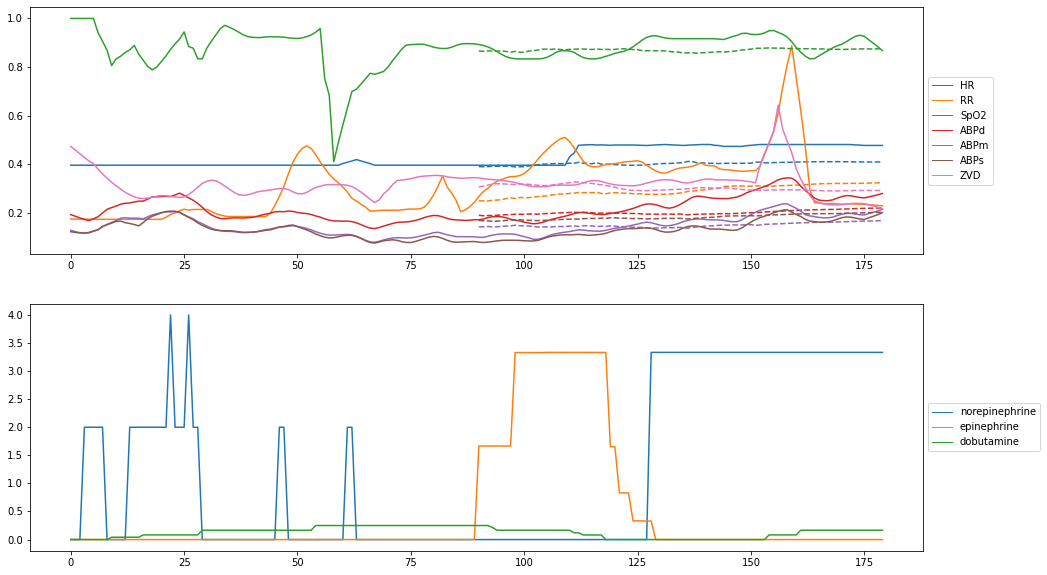

In [5]:
idx = 456
# idx = 15

x = dataset_test[idx]['data']
x[np.where(x==-1)] = np.nan
x_ = X_reconstructed[idx]
x_[np.where(x_==-1)] = np.nan
x_next = X_pred[idx]
x_next[np.where(x_next==-1)] = np.nan
x_med = dataset_test[idx]['med']
x_med[np.where(x_med)==0] = np.nan

labels = selected_physio

fig, ax = plt.subplots(2,1,figsize=(16,10))
colors = plt.cm.tab10
for j in range(7):
    ax[0].plot(range(180), x[:,j], '-', color=colors(j))
#     ax.plot(range(90), x_[:,j], '--', color=colors(j))
    ax[0].plot(range(90, 180), x_next[:,j], '--', color=colors(j))

lines = [Line2D([0], [0], color=colors(i), lw=1, label=labels[i]) for i in range(7)]
ax[0].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));


lines = []
for med in MED_BENCHMARK[:3]:
    idx_med = MED_BENCHMARK.index(med)
    med_raw =  de_norm(x_med[:, idx_med], med)
    ax[1].plot(med_raw, label=med, color=colors(idx_med))
    lines.append(Line2D([0], [0], color=colors(idx_med), lw=1, label=med))
ax[1].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));

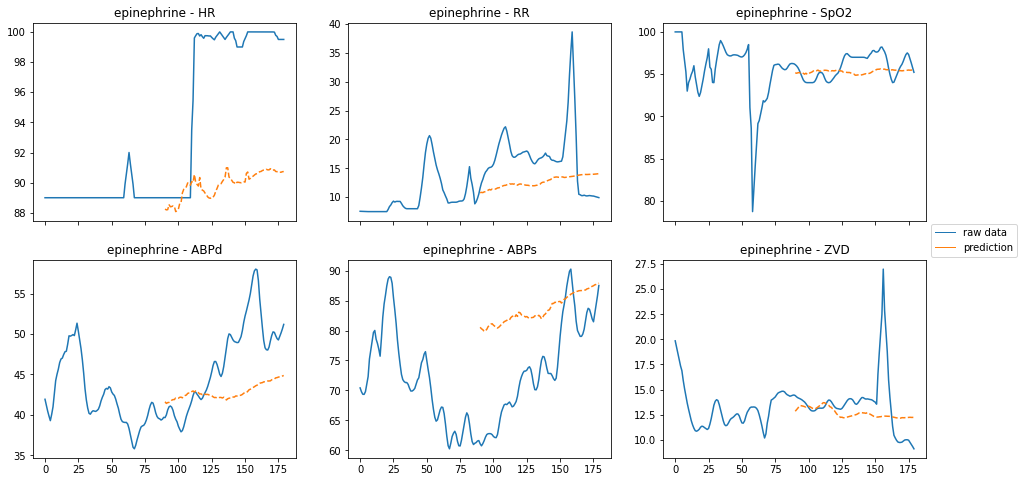

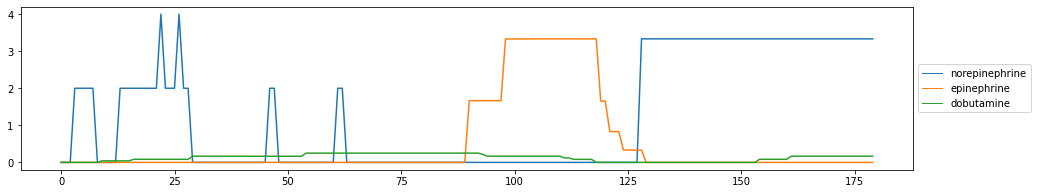

In [6]:
# idx = 30
# idx = 66
# idx = 15
idx = 456


x = dataset_test[idx]['data']
x[np.where(x==-1)] = np.nan
x_ = X_reconstructed[idx]
x_[np.where(x_==-1)] = np.nan
x_next = X_pred[idx]
x_next[np.where(x_next==-1)] = np.nan
meds = ['dobutamine', 'epinephrine', 'norepinephrine']
med = meds[np.where(dataset_test[idx]['med_label']==1)[0].item()]
x_med = dataset_test[idx]['med']
x_med[np.where(x_med==0)] = np.nan

labels = selected_physio

fig, ax = plt.subplots(2,3,figsize=(16,8), sharex=True)
colors = plt.cm.tab10
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPd',
    'ABPs',
    'ZVD',
]
for i, physio in enumerate(physio_plot):
    idx_physio = PHYSIO_BENCHMARK.index(physio)
    
    x_raw = de_norm(x[:,idx_physio], physio)
    x_pred = de_norm(x_next[:,idx_physio], physio)
    
    ax[i//3][i%3].plot(range(180), x_raw, '-', color=colors(0))
    ax[i//3][i%3].plot(range(90, 180), x_pred, '--', color=colors(1))
    ax[i//3][i%3].set_title(f"{med} - {physio}")
lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
         Line2D([0], [0], color=colors(1), lw=1, label='prediction')]
plt.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.1));    

    
fig, ax = plt.subplots(1, 1, figsize=(16,3))
lines = []
for med in MED_BENCHMARK[:3]:
    idx_med = MED_BENCHMARK.index(med)
    med_raw =  de_norm(x_med[:, idx_med], med)
    ax.plot(med_raw, label=med, color=colors(idx_med))
    lines.append(Line2D([0], [0], color=colors(idx_med), lw=1, label=med))
ax.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));

# Response for different vasoactive agents

In [7]:
meds = ['dobutamine', 'epinephrine', 'norepinephrine']

data_raw = {med: [] for med in meds}
data_pred = {med: [] for med in meds}
for idx, sample in tqdm(enumerate(dataset_test)):
    med = meds[np.where(sample['med_label']==1)[0].item()]
    raw = sample['data']
    raw[np.where(raw==-1)] = np.nan
    data_raw[med].append(raw[None,:,:])
    data_pred[med].append(np.concatenate((X_reconstructed[idx], X_pred[idx]), axis=0)[None,:,:])

798it [01:28,  8.99it/s]


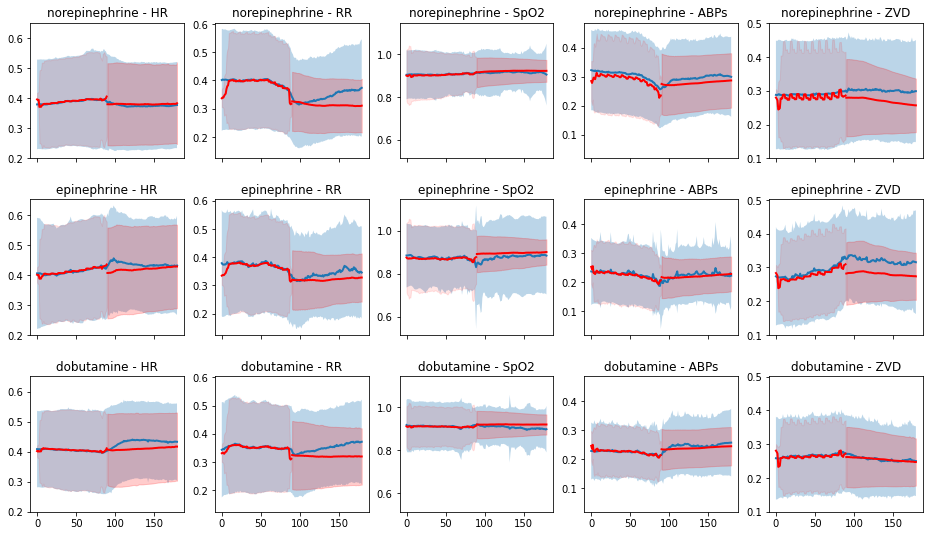

In [8]:
fig, ax = plt.subplots(3, 5, figsize=(16,9), sharex=True, sharey='col')
plt.subplots_adjust(hspace=.3, wspace=.2)
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPs',
    'ZVD',
#     'OUTurine/h',
]


for i, med in enumerate(MED_BENCHMARK[:3]):
    data = np.concatenate(data_raw[med], axis=0)
    mean_raw = np.nanmean(data, axis=0)
    std_raw = np.nanstd(data, axis=0)

    pred = np.concatenate(data_pred[med], axis=0)
    mean = pred.mean(0)
    std = pred.std(0)
    for j, physio in enumerate(physio_plot):
        idx_physio = PHYSIO_BENCHMARK.index(physio)
        
        
        ax[i][j].plot(mean_raw[:,idx_physio], linewidth=2);
        ax[i][j].fill_between(range(180), 
                        mean_raw[:,idx_physio]-std_raw[:,idx_physio], 
                        mean_raw[:,idx_physio]+std_raw[:,idx_physio], 
                        alpha=.3)
        
        ax[i][j].plot(range(90), mean[:90,idx_physio], linewidth=2, color='r');
        ax[i][j].fill_between(range(90), 
                        mean[:90,idx_physio]-std[:90,idx_physio], 
                        mean[:90,idx_physio]+std[:90,idx_physio], 
                        alpha=.1, color='r')
        
        ax[i][j].plot(range(90,180), mean[90:,idx_physio], linewidth=2, color='r');
        ax[i][j].fill_between(range(90, 180), 
                        mean[90:,idx_physio]-std[90:,idx_physio], 
                        mean[90:,idx_physio]+std[90:,idx_physio], 
                        alpha=.2, color='r')
        
        
    #     ax.set_ylim(0.2, 0.4)
        ax[i][j].set_title(f'{med} - {physio}')

# Model with data smoothing, interpolation, and medication stratification

In [123]:
model_path = 'models/VASO_PHYSIO_PRED/CNN-196hidden-8som-3r-0.1dropout-8-0.0005/version_5/'
model_file = os.path.join(model_path, "epoch44-val_loss_pred0.05552.ckpt")
config_file = os.path.join(model_path, "model_config.p")
config = pickle.load(open(config_file, 'rb'))

device = 'cuda'

DATA = load_train_test_dataset(
        batchsize=config['batchsize'],
        sample_dict_file='sample_dict_vasopressor_filtered70.p',
        RANDOMSEED=RANDOMSEED, norm=True, smooth=True, interpolate=True)
pid_valid = DATA['pid_valid']
norm_params = DATA['norm_params']
norm_params_info = DATA['norm_params_info']
patient_info = DATA['patient_info']
dataset_train = DATA['dataset_train']
dataset_val = DATA['dataset_val']
dataset_test = DATA['dataset_test']
loader_train = DATA['loader_train']
loader_val = DATA['loader_val']
loader_test = DATA['loader_test']
del DATA

# Train model


model = VASO_PHYSIO_PRED.load_from_checkpoint(checkpoint_path=model_file, config=config)
model.to(device)
model.eval()

X_reconstructed = []
X_pred = []
for X in tqdm(loader_test):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = X[k][j].to(device)
        else:
            X[k] = X[k].to(device)
    X_, X_next = model(X)
    X_reconstructed.append(X_.cpu().detach().numpy())
    X_pred.append(X_next.cpu().detach().numpy())
    
X_reconstructed = np.concatenate(X_reconstructed, axis=0)
X_pred = np.concatenate(X_pred, axis=0)

Loading dataset


100%|█| 88/88 [00:10<00:00,


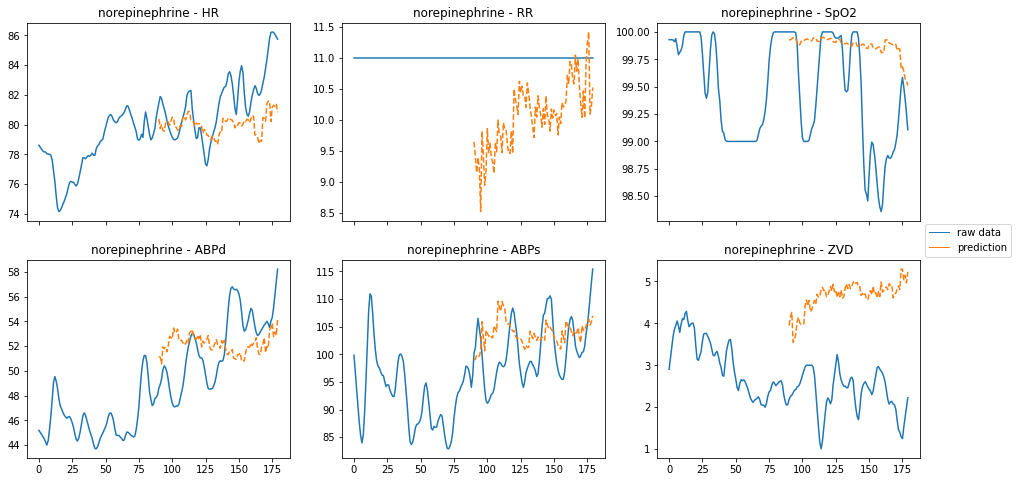

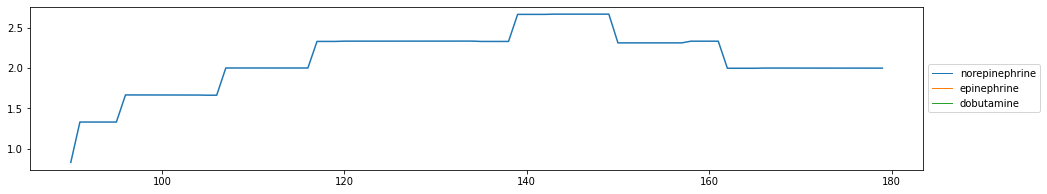

In [45]:
# plot_vital_pred(333)
plot_vital_pred(333)

In [39]:
dataset_test[333]['med']

array([[-2.79098137e-06, -1.70346087e-06, -1.81851242e-04, ...,
        -3.34437611e-03, -1.99702973e-06, -1.04167752e-05],
       [-2.79098137e-06, -1.70346087e-06, -1.81851242e-04, ...,
        -3.34437611e-03, -1.99702973e-06, -1.04167752e-05],
       [-2.79098137e-06, -1.70346087e-06, -1.81851242e-04, ...,
        -3.34437611e-03, -1.99702973e-06, -1.04167752e-05],
       ...,
       [ 2.39737432e-02, -1.70346087e-06, -1.81851242e-04, ...,
        -3.34437611e-03, -1.99702973e-06, -1.04167752e-05],
       [ 2.39737432e-02, -1.70346087e-06, -1.81851242e-04, ...,
        -3.34437611e-03, -1.99702973e-06, -1.04167752e-05],
       [ 2.39737432e-02, -1.70346087e-06, -1.81851242e-04, ...,
        -3.34437611e-03, -1.99702973e-06, -1.04167752e-05]])

100%|█| 697/697 [01:18<00:0


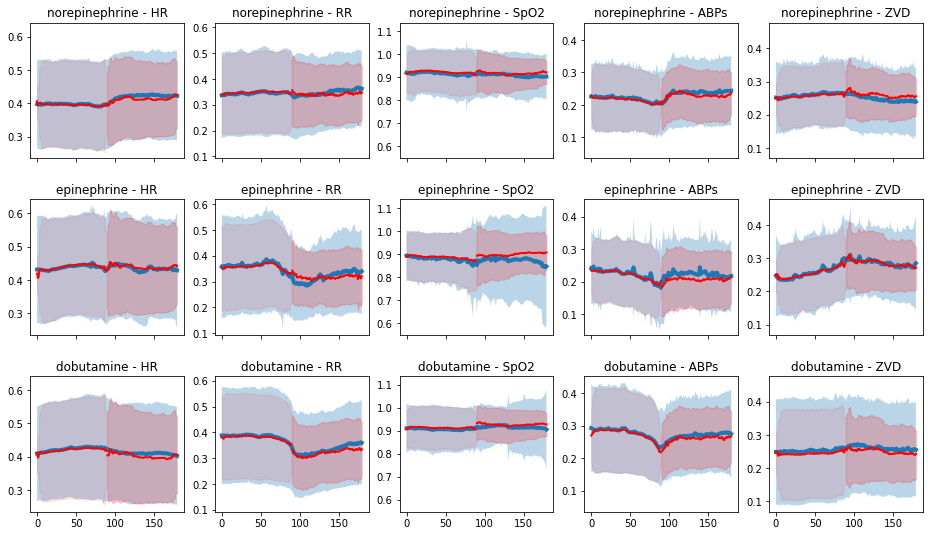

In [36]:
meds = ['dobutamine', 'epinephrine', 'norepinephrine']

data_raw = {med: [] for med in meds}
data_pred = {med: [] for med in meds}
for idx, sample in enumerate(tqdm(dataset_test)):
    med = meds[np.where(sample['med_label']==1)[0].item()]
    raw = sample['data']
    raw[np.where(raw==-1)] = np.nan
    data_raw[med].append(raw[None,:,:])
    data_pred[med].append(np.concatenate((X_reconstructed[idx], X_pred[idx]), axis=0)[None,:,:])


fig, ax = plt.subplots(3, 5, figsize=(16,9), sharex=True, sharey='col')
plt.subplots_adjust(hspace=.3, wspace=.2)
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPs',
    'ZVD',
#     'OUTurine/h',
]


for i, med in enumerate(MED_BENCHMARK[:3]):
    data = np.concatenate(data_raw[med], axis=0)
    mean_raw = np.nanmean(data, axis=0)
    std_raw = np.nanstd(data, axis=0)

    pred = np.concatenate(data_pred[med], axis=0)
    mean = pred.mean(0)
    std = pred.std(0)
    for j, physio in enumerate(physio_plot):
        idx_physio = PHYSIO_BENCHMARK.index(physio)
        
        
        ax[i][j].plot(mean_raw[:,idx_physio], linewidth=4);
        ax[i][j].fill_between(range(180), 
                        mean_raw[:,idx_physio]-std_raw[:,idx_physio], 
                        mean_raw[:,idx_physio]+std_raw[:,idx_physio], 
                        alpha=.3)
        
        ax[i][j].plot(range(90), mean[:90,idx_physio], linewidth=2, color='r');
        ax[i][j].fill_between(range(90), 
                        mean[:90,idx_physio]-std[:90,idx_physio], 
                        mean[:90,idx_physio]+std[:90,idx_physio], 
                        alpha=.1, color='r')
        
        ax[i][j].plot(range(90,180), mean[90:,idx_physio], linewidth=2, color='r');
        ax[i][j].fill_between(range(90, 180), 
                        mean[90:,idx_physio]-std[90:,idx_physio], 
                        mean[90:,idx_physio]+std[90:,idx_physio], 
                        alpha=.2, color='r')
        
        
    #     ax.set_ylim(0.2, 0.4)
        ax[i][j].set_title(f'{med} - {physio}')

# Save plots

In [171]:
save_path = 'plots/vasoactive_agents/'

for idx in tqdm(range(len(dataset_test))):
    med, fig = gridplot_vital_pred(idx)
    save_to = os.path.join(save_path, med)
    Path(save_to).mkdir(parents=True, exist_ok=True)
    fig.savefig(os.path.join(save_to, f'{idx}.png'),  dpi=600, bbox_inches='tight')
    plt.close(fig)

100%|█| 697/697 [44:11<00:0


('norepinephrine', <Figure size 1152x720 with 7 Axes>)

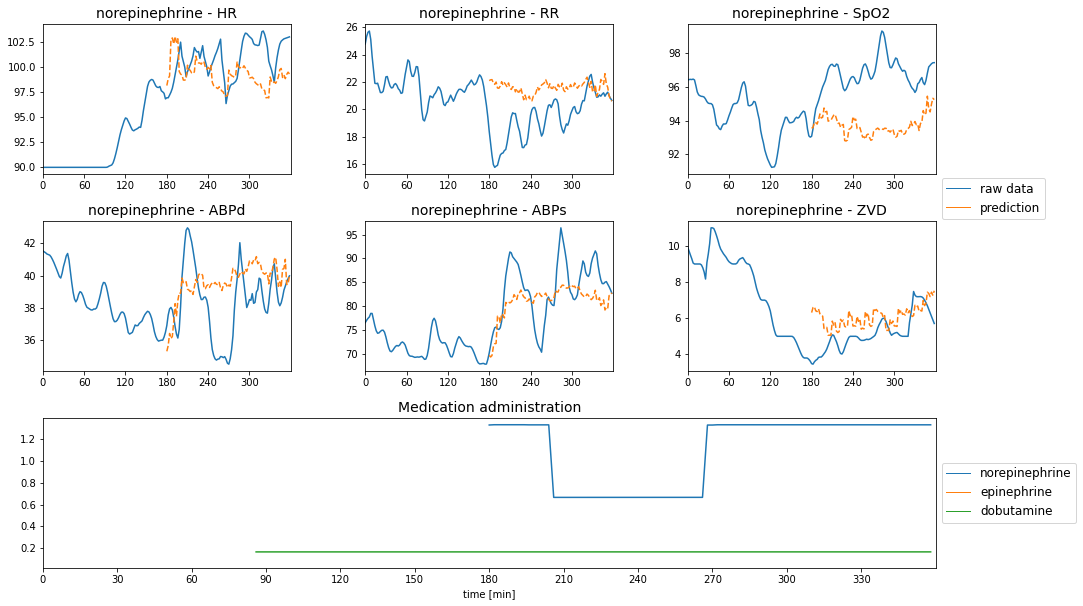

In [173]:
gridplot_vital_pred(89)

# Response to different medication dosage 

In [11]:
from copy import deepcopy

In [12]:
len(data_raw['norepinephrine']), len(data_raw['epinephrine']), len(data_raw['dobutamine'])

(416, 97, 285)

100%|█████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  9.72it/s]


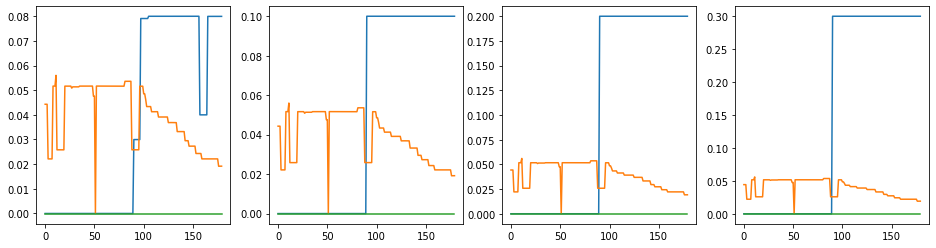

In [20]:
idx = 222

sample = dataset_test[idx]

sample1 =  deepcopy(sample)
sample1['med'][90:, 0] = 0.1

sample2 =  deepcopy(sample)
sample2['med'][90:, 0] = 0.2

sample3 =  deepcopy(sample)
sample3['med'][90:, 0] = 0.3

samples = [sample1, sample2, sample3]

fig, ax = plt.subplots(1, 4, figsize=(16,4))
ax[0].plot(sample['med'][:,:3])
for i in range(3):
    ax[i+1].plot(samples[i]['med'][:,:3])

loader = DataLoader(samples)

reconsts = []
preds = []
for X in tqdm(loader):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = X[k][j].to(device)
        else:
            X[k] = X[k].to(device)
    X_, X_next = model(X)
    reconsts.append(X_.cpu().detach().numpy())
    preds.append(X_next.cpu().detach().numpy())
    
reconsts = np.concatenate(reconsts, axis=0)
preds = np.concatenate(preds, axis=0)



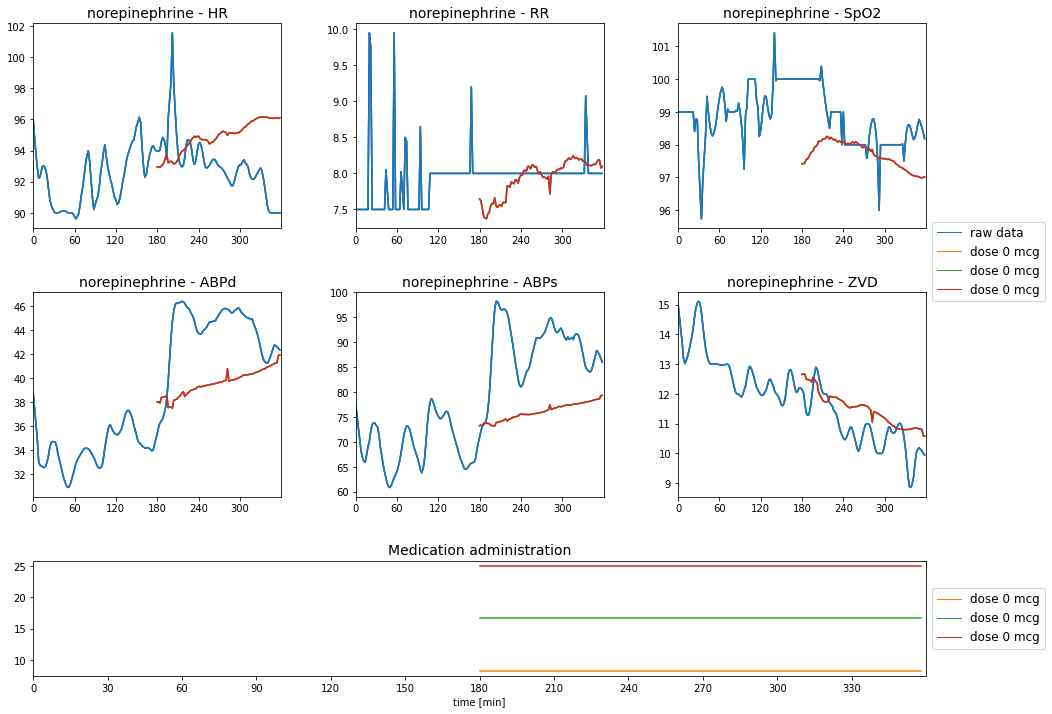

In [21]:
fig = plt.figure(figsize=(16,12))
gs = fig.add_gridspec(8,3)
ax = []
for i in range(6):
    if i == 0:
        ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3]))
    else:
        ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3], sharex=ax[0]))
ax.append(fig.add_subplot(gs[6:,:]))

colors = plt.cm.tab10
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPd',
    'ABPs',
    'ZVD',
]

legends = []
for j in range(3):
    legends.append(f"dose {round(de_norm(samples[j]['med'][:,0], med)[-1])} mcg")

for i, physio in enumerate(physio_plot):
    for j in range(3):
        idx_physio = PHYSIO_BENCHMARK.index(physio)

        sample = samples[j]
        x = sample['data']
        x[np.where(x==-1)] = np.nan
        x_ = X_reconstructed[idx]
        x_[np.where(x_==-1)] = np.nan
        x_next = preds[j]
        x_next[np.where(x_next==-1)] = np.nan

        x_raw = de_norm(x[:,idx_physio], physio)
        x_pred = de_norm(x_next[:,idx_physio], physio)
        med_label = 'norepinephrine'

        ax[i].plot(range(180), x_raw, '-', color=colors(0))
        ax[i].plot(range(90, 180), x_pred, '-', color=colors(j+1))
        ax[i].set_title(f"{med_label} - {physio}", fontsize=14)
lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
         Line2D([0], [0], color=colors(1), lw=1, label=legends[0]),
         Line2D([0], [0], color=colors(2), lw=1, label=legends[1]),
         Line2D([0], [0], color=colors(3), lw=1, label=legends[2])]
ax[5].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.15), fontsize=12); 
ax[5].set_xlim([0, 180])
ax[5].set_xticks(np.arange(0, 180, 30))
ax[5].set_xticklabels(np.arange(0, 360, 60))


lines = []
med = 'norepinephrine'
for j in range(3):
    x_med = samples[j]['med']
#     x_med[np.where(x_med==0)] = np.nan

    idx_med = MED_BENCHMARK.index(med)
    med_raw =  de_norm(x_med[:, idx_med], med)
    med_raw[np.where(med_raw==0)] = np.nan
    ax[6].plot(med_raw, label=med, color=colors(j+1))
    lines.append(Line2D([0], [0], color=colors(j+1), lw=1, label=legends[j]))
ax[6].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12);
ax[6].set_xlim([0, 180])
ax[6].set_xticks(np.arange(0, 180, 15))
ax[6].set_xticklabels(np.arange(0, 360, 30))
ax[6].set_xlabel('time [min]')
ax[6].set_title('Medication administration', fontsize=14)

plt.subplots_adjust(hspace=2.5, wspace=.3)

In [22]:
preds.shape

(3, 90, 7)

In [26]:
preds[1, :, 1] - preds[0, :, 1]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.], dtype=float32)

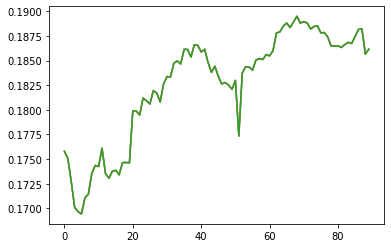

In [25]:
plt.plot(preds[:, :, 1].T);

In [12]:
savepath = 'plots/vasoactive_agents/dosage_response_mono'
Path(savepath).mkdir(parents=True, exist_ok=True)

for idx in tqdm(range(100)):
    sample = dataset_test[idx]
    sample1 =  deepcopy(sample)
    sample1['med'][90:, 0] = 0.01
    sample2 =  deepcopy(sample)
    sample2['med'][90:, 0] = 0.02
    sample3 =  deepcopy(sample)
    sample3['med'][90:, 0] = 0.05
    samples = [sample1, sample2, sample3]
    loader = DataLoader(samples)

    reconsts = []
    preds = []
    for X in loader:
        for k in X:
            if type(X[k]) is dict:
                for j in X[k]:
                    X[k][j] = X[k][j].to(device)
            else:
                X[k] = X[k].to(device)
        X_, X_next = model(X)
        reconsts.append(X_.cpu().detach().numpy())
        preds.append(X_next.cpu().detach().numpy())

    reconsts = np.concatenate(reconsts, axis=0)
    preds = np.concatenate(preds, axis=0)



    labels = selected_physio

    fig = plt.figure(figsize=(16,12))
    gs = fig.add_gridspec(8,3)
    ax = []
    for i in range(6):
        if i == 0:
            ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3]))
        else:
            ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3], sharex=ax[0]))
    ax.append(fig.add_subplot(gs[6:,:]))

    colors = plt.cm.tab10
    physio_plot = [
        'HR',
        'RR',
        'SpO2',
        'ABPd',
        'ABPs',
        'ZVD',
    ]

    legends = []
    for j in range(3):
        legends.append(f"dose {round(de_norm(samples[j]['med'][:,0], med)[-1])} mcg")

    for i, physio in enumerate(physio_plot):
        for j in range(3):
            idx_physio = PHYSIO_BENCHMARK.index(physio)

            sample = samples[j]
            x = sample['data']
            x[np.where(x==-1)] = np.nan
            x_ = X_reconstructed[idx]
            x_[np.where(x_==-1)] = np.nan
            x_next = preds[j]
            x_next[np.where(x_next==-1)] = np.nan

            x_raw = de_norm(x[:,idx_physio], physio)
            x_pred = de_norm(x_next[:,idx_physio], physio)
            med_label = 'norepinephrine'

            ax[i].plot(range(180), x_raw, '-', color=colors(0))
            ax[i].plot(range(90, 180), x_pred, '-', color=colors(j+1))
            ax[i].set_title(f"{med_label} - {physio}", fontsize=14)
    lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
             Line2D([0], [0], color=colors(1), lw=1, label=legends[0]),
             Line2D([0], [0], color=colors(2), lw=1, label=legends[1]),
             Line2D([0], [0], color=colors(3), lw=1, label=legends[2])]
    ax[5].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.15), fontsize=12); 
    ax[5].set_xlim([0, 180])
    ax[5].set_xticks(np.arange(0, 180, 30))
    ax[5].set_xticklabels(np.arange(0, 360, 60))


    lines = []
    med = 'norepinephrine'
    for j in range(3):
        x_med = samples[j]['med']
    #     x_med[np.where(x_med==0)] = np.nan

        idx_med = MED_BENCHMARK.index(med)
        med_raw =  de_norm(x_med[:, idx_med], med)
        med_raw[np.where(med_raw==0)] = np.nan
        ax[6].plot(med_raw, label=med, color=colors(j+1))
        lines.append(Line2D([0], [0], color=colors(j+1), lw=1, label=legends[j]))
    ax[6].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12);
    ax[6].set_xlim([0, 180])
    ax[6].set_xticks(np.arange(0, 180, 15))
    ax[6].set_xticklabels(np.arange(0, 360, 30))
    ax[6].set_xlabel('time [min]')
    ax[6].set_title('Medication administration', fontsize=14)

    plt.subplots_adjust(hspace=2.5, wspace=.3)
    
    fig.savefig(os.path.join(savepath, f"{idx}.png"), dpi=600, bbox_inches='tight')
    plt.close(fig)

100%|█████████████████████████████████████████████████████████████████████| 100/100 [07:07<00:00,  4.28s/it]


In [235]:
for j in range(3):
    print(de_norm(samples[j]['med'][:,0], med)[-1])

0.8334811673299529
1.666729776525569
4.166475604112417


In [ ]:
sample['med'].shapee

In [255]:
med_ = []

for sample in tqdm(dataset_test):
    med_label = sample['med_label']
    med_.append(sample['med'])

100%|█| 697/697 [01:19<00:0


In [265]:
med_statistics = np.array(med_)
med_statistics[np.where(med_statistics==0)] = np.nan

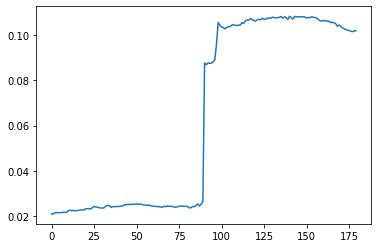

In [268]:
plt.plot(np.nanmean(med_statistics, axis=0)[:, 2])


In [15]:
data_raw['norepinephrine'].shape

AttributeError: 'list' object has no attribute 'shape'

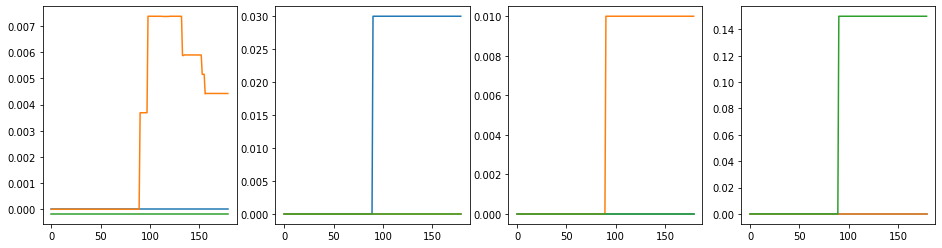

In [271]:
idx = 400

sample = dataset_test[idx]

c

samples = [sample1, sample2, sample3]

fig, ax = plt.subplots(1, 4, figsize=(16,4))
ax[0].plot(sample['med'][:,:3])
for i in range(3):
    ax[i+1].plot(samples[i]['med'][:,:3])

# loader = DataLoader(samples)

# reconsts = []
# preds = []
# for X in tqdm(loader):
#     for k in X:
#         if type(X[k]) is dict:
#             for j in X[k]:
#                 X[k][j] = X[k][j].to(device)
#         else:
#             X[k] = X[k].to(device)
#     X_, X_next = model(X)
#     reconsts.append(X_.cpu().detach().numpy())
#     preds.append(X_next.cpu().detach().numpy())
    
# reconsts = np.concatenate(reconsts, axis=0)
# preds = np.concatenate(preds, axis=0)



In [1]:
savepath = 'plots/vasoactive_agents/med_response'
Path(savepath).mkdir(parents=True, exist_ok=True)

for idx in tqdm(range(1)):
    sample = dataset_test[idx]
    sample1 =  deepcopy(sample)
    sample1['med'][:, :3] = 0
    sample1['med'][90:, 0] = 0.1

    sample2 =  deepcopy(sample)
    sample2['med'][:, :3] = 0
    sample2['med'][90:, 1] = 0.1

    sample3 =  deepcopy(sample)
    sample3['med'][:, :3] = 0
    sample3['med'][90:, 2] = 1

    reconsts = []
    preds = []
    for X in loader:
        for k in X:
            if type(X[k]) is dict:
                for j in X[k]:
                    X[k][j] = X[k][j].to(device)
            else:
                X[k] = X[k].to(device)
        X_, X_next = model(X)
        reconsts.append(X_.cpu().detach().numpy())
        preds.append(X_next.cpu().detach().numpy())

    reconsts = np.concatenate(reconsts, axis=0)
    preds = np.concatenate(preds, axis=0)



    labels = selected_physio

    fig = plt.figure(figsize=(16,12))
    gs = fig.add_gridspec(8,3)
    ax = []
    for i in range(6):
        if i == 0:
            ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3]))
        else:
            ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3], sharex=ax[0]))
    ax.append(fig.add_subplot(gs[6:,:]))

    colors = plt.cm.tab10
    physio_plot = [
        'HR',
        'RR',
        'SpO2',
        'ABPd',
        'ABPs',
        'ZVD',
    ]

    legends = MED_BENCHMARK[:3]
    for j in range(3):
        legends.append(legends[j] + f" - {round(de_norm(samples[j]['med'][:,j], med[j])[-1])} mcg")

    for i, physio in enumerate(physio_plot):
        for j in range(3):
            idx_physio = PHYSIO_BENCHMARK.index(physio)

            sample = samples[j]
            x = sample['data']
            x[np.where(x==-1)] = np.nan
            x_ = X_reconstructed[idx]
            x_[np.where(x_==-1)] = np.nan
            x_next = preds[j]
            x_next[np.where(x_next==-1)] = np.nan

            x_raw = de_norm(x[:,idx_physio], physio)
            x_pred = de_norm(x_next[:,idx_physio], physio)
            med_label = 'norepinephrine'

            ax[i].plot(range(180), x_raw, '-', color=colors(0))
            ax[i].plot(range(90, 180), x_pred, '-', color=colors(j+1))
            ax[i].set_title(f"{med_label} - {physio}", fontsize=14)
    lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
             Line2D([0], [0], color=colors(1), lw=1, label=legends[0]),
             Line2D([0], [0], color=colors(2), lw=1, label=legends[1]),
             Line2D([0], [0], color=colors(3), lw=1, label=legends[2])]
    ax[5].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.15), fontsize=12); 
    ax[5].set_xlim([0, 180])
    ax[5].set_xticks(np.arange(0, 180, 30))
    ax[5].set_xticklabels(np.arange(0, 360, 60))


    lines = []
    med = MED_BENCHMARK[:3]
    for j in range(3):
        x_med = samples[j]['med']
    #     x_med[np.where(x_med==0)] = np.nan

        idx_med = MED_BENCHMARK.index(med[j])
        med_raw =  de_norm(x_med[:, idx_med], med[j])
        med_raw[np.where(med_raw==0)] = np.nan
        ax[6].plot(med_raw, label=med[j], color=colors(j+1))
        lines.append(Line2D([0], [0], color=colors(j+1), lw=1, label=legends[j]))
    ax[6].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12);
    ax[6].set_xlim([0, 180])
    ax[6].set_xticks(np.arange(0, 180, 15))
    ax[6].set_xticklabels(np.arange(0, 360, 30))
    ax[6].set_xlabel('time [min]')
    ax[6].set_title('Medication administration', fontsize=14)

    plt.subplots_adjust(hspace=2.5, wspace=.3)
    
    fig.savefig(os.path.join(savepath, f"{idx}.png"), dpi=600, bbox_inches='tight')
#     plt.close(fig)

NameError: name 'Path' is not defined

In [277]:
samples[j]['med']

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         3.34659308e-03, -1.99702973e-06, -1.04167752e-05],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         3.34659308e-03, -1.99702973e-06, -1.04167752e-05],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         3.34659308e-03, -1.99702973e-06, -1.04167752e-05],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  1.50000000e-01, ...,
         3.34659308e-03,  9.97577738e-03,  6.24902343e-02],
       [ 0.00000000e+00,  0.00000000e+00,  1.50000000e-01, ...,
         3.34659308e-03,  9.97577738e-03,  6.24902343e-02],
       [ 0.00000000e+00,  0.00000000e+00,  1.50000000e-01, ...,
         3.34659308e-03,  9.97577738e-03,  6.24902343e-02]])